## Overview
This notebook evaluates CNN robustness by generating adversarial perturbations:
- Create adversarial examples (small perturbations added to images)
- Test CNN predictions on perturbed images
- Compare clean vs adversarial accuracy
- Identify which classes are most vulnerable
## Research Question
**How robust is the CNN to small, imperceptible perturbations to input images?**
This is the core of adversarial robustness research:
- Real-world impact: Could adversaries fool security systems?
- Model reliability: Does small noise break predictions?
- Interpretability: Which features make CNN vulnerable?
## Adversarial Perturbation Methods
We'll use **Additive Gaussian Noise** - the simplest, most interpretable approach:
1. Generate random noise N(0, σ)
2. Scale by perturbation magnitude ε
3. Add to image: X_adv = X + ε * noise
4. Clip to [0, 1] to maintain valid pixel range
**Why Additive Noise?**
- Mimics real-world sensor noise
- Easy to interpret and visualize
- Standard baseline in robustness literature


In [14]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load test data
with open('data/processed/cifar10_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)
    X_test = data['X_test']
    y_test = data['y_test']
    class_names = data['class_names']

# Load trained model
model = keras.models.load_model('models/cnn_trained.keras')

# Load training results to get clean predictions
with open('results/training_results.pkl', 'rb') as f:
    training_results = pickle.load(f)
    y_pred_clean = training_results['y_pred']
    baseline_accuracy = training_results['test_accuracy']

print("Data and model loaded")

Data and model loaded



## Adversarial Perturbation Methodology
### Perturbation Magnitude: ε (epsilon)
We test multiple perturbation strengths to understand the robustness curve:
**ε Values Tested:**
- 0.0: No perturbation (baseline)
- 0.01: Very small noise (barely visible)
- 0.05: Small noise (human-imperceptible)
- 0.10: Medium noise (noticeable but not overwhelming)
- 0.20: Large noise (clearly visible degradation)
- 0.30: Severe noise (severely corrupted images)
### Why Multiple ε Values?
- **ε = 0.01-0.05:** Measures real adversarial vulnerability (imperceptible attacks)
- **ε = 0.10-0.30:** Shows how much noise breaks the model (upper bound)
- **Curve Shape:** Reveals if robustness degrades gracefully or catastrophically
### Perturbation Formula
X_adv = Clip(X + ε * N(0, 1), 0, 1)
where:
X = original image (normalized to [0,1])
ε = perturbation magnitude (hyperparameter)
N(0, 1) = Gaussian noise (mean=0, std=1)
Clip(..., 0, 1) = bound result to valid pixel range
### Why Gaussian Noise?
1. **Interpretability:** Easy to understand and visualize
2. **Realism:** Mimics sensor noise in real cameras
3. **Gradual degradation:** Enables robustness curve analysis
4. **Standard baseline:** Used in published adversarial robustness papers
### Connection to EDA
from brightness analysis:
- Airplane (0.558) & Ship (0.523): Bright images, high SNR
- Frog (0.418) & Deer (0.438): Dark images, lower SNR
**Hypothesis:** Dark images may be more vulnerable to noise because:
- Lower pixel intensities = smaller signal-to-noise ratio
- Noise artifacts more visible in dark regions
- CNN relies more on contrast in bright images


In [15]:

# Define perturbation magnitudes to test
epsilon_values = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30]

print("\n" + "="*70)
print("GENERATING ADVERSARIAL EXAMPLES")
print("="*70)

# Dictionary to store results
adversarial_results = {
    'epsilon_values': epsilon_values,
    'accuracies': [],
    'predictions': [],
    'X_adv_dict': {}
}

for eps in epsilon_values:
    print(f"\nEpsilon = {eps:.2f}")
    
    if eps == 0.0:
        # No perturbation (baseline)
        X_adv = X_test.copy()
    else:
        # Generate Gaussian noise
        noise = np.random.normal(0, 1, X_test.shape)
        
        # Apply perturbation: X_adv = X + ε * noise
        X_adv = X_test + eps * noise
        
        # Clip to valid range [0, 1]
        X_adv = np.clip(X_adv, 0, 1)
    
    # Get predictions on adversarial examples
    y_pred_adv = model.predict(X_adv, verbose=0)
    y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
    
    # Compute accuracy
    acc_adv = accuracy_score(y_test, y_pred_adv_labels)
    adversarial_results['accuracies'].append(acc_adv)
    adversarial_results['predictions'].append(y_pred_adv_labels)
    adversarial_results['X_adv_dict'][eps] = X_adv
    
    # Print metrics
    accuracy_drop = (baseline_accuracy - acc_adv) * 100
    print(f"  Accuracy: {acc_adv:.4f}")
    print(f"  Accuracy Drop: {accuracy_drop:.2f}%")

print("\n" + "="*50)
print(" Adversarial examples generated for all ε values")
print("="*50)


GENERATING ADVERSARIAL EXAMPLES

Epsilon = 0.00
  Accuracy: 0.7573
  Accuracy Drop: 0.00%

Epsilon = 0.01
  Accuracy: 0.7556
  Accuracy Drop: 0.17%

Epsilon = 0.05
  Accuracy: 0.6649
  Accuracy Drop: 9.24%

Epsilon = 0.10
  Accuracy: 0.4379
  Accuracy Drop: 31.94%

Epsilon = 0.20
  Accuracy: 0.1990
  Accuracy Drop: 55.83%

Epsilon = 0.30
  Accuracy: 0.1402
  Accuracy Drop: 61.71%

 Adversarial examples generated for all ε values



## Robustness Curve: Accuracy vs Perturbation Magnitude
**What This Shows:**
- Y-axis: Model accuracy on adversarially perturbed images
- X-axis: Perturbation magnitude (ε)
- Steep curve: Model is vulnerable (breaks easily with small noise)
- Flat curve: Model is robust (maintains accuracy despite noise)
**Interpretation:**
- Sharp drop at small ε: Adversarial vulnerability
- Gradual decline: Graceful degradation
- Area under curve: Overall robustness score

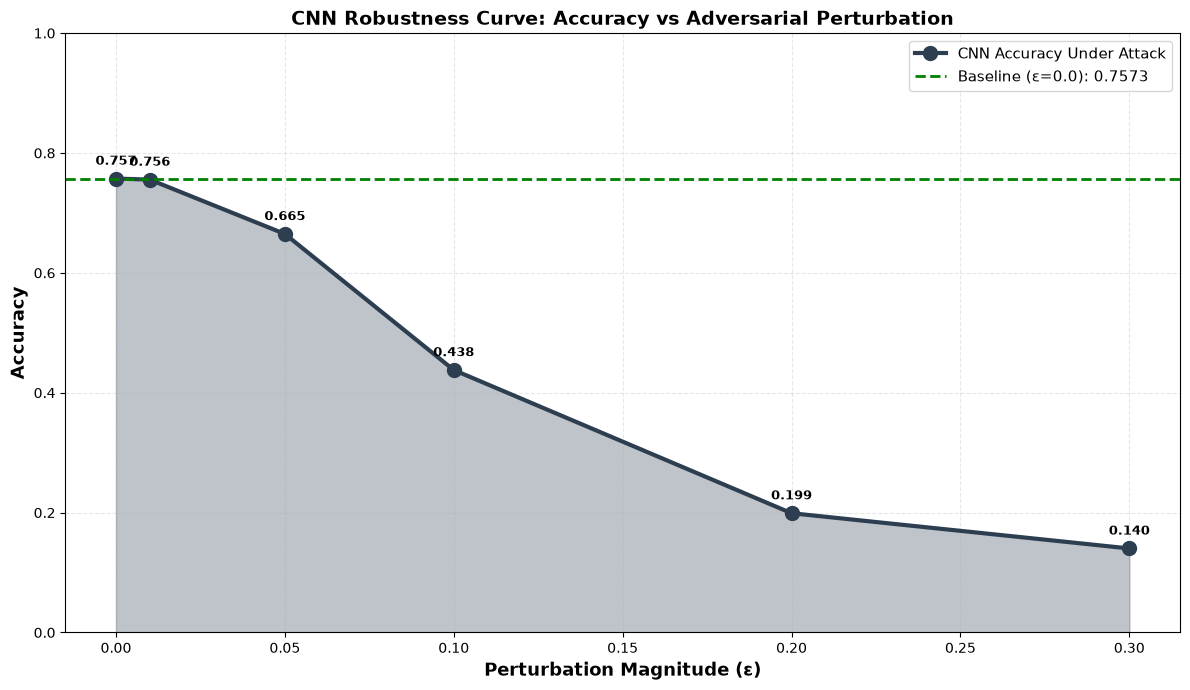

Saved: figures/05_robustness_curve.png

ROBUSTNESS ANALYSIS

Accuracy at each perturbation level:
  ε = 0.00: 0.7573 (+0.00% change)
  ε = 0.01: 0.7556 (+0.17% change)
  ε = 0.05: 0.6649 (+9.24% change)
  ε = 0.10: 0.4379 (+31.94% change)
  ε = 0.20: 0.1990 (+55.83% change)
  ε = 0.30: 0.1402 (+61.71% change)

Critical ε (where accuracy < 50%): 0.10
→ Model becomes unreliable above this threshold


In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
# Plot robustness curve
accuracies = np.array(adversarial_results['accuracies'])
epsilons = np.array(epsilon_values)

ax.plot(epsilons, accuracies, marker='o', linewidth=3, markersize=10, 
        color='#2c3e50', label='CNN Accuracy Under Attack')
ax.axhline(y=baseline_accuracy, color='green', linestyle='--', linewidth=2, 
           label=f'Baseline (ε=0.0): {baseline_accuracy:.4f}')
ax.fill_between(epsilons, accuracies, alpha=0.3, color='#2c3e50')

ax.set_xlabel('Perturbation Magnitude (ε)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('CNN Robustness Curve: Accuracy vs Adversarial Perturbation', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.0])
ax.legend(fontsize=11, loc='upper right')

# Add annotations
for eps, acc in zip(epsilons, accuracies):
    ax.annotate(f'{acc:.3f}', xy=(eps, acc), xytext=(0, 10), 
                textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/05_robustness_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: figures/05_robustness_curve.png")

# Analysis
print("\n" + "="*30)
print("ROBUSTNESS ANALYSIS")
print("="*30)

# Find critical epsilon (where accuracy drops below 50%)
critical_eps = None
for eps, acc in zip(epsilons, accuracies):
    if acc < 0.5 and critical_eps is None:
        critical_eps = eps

print(f"\nAccuracy at each perturbation level:")
for eps, acc in zip(epsilons, accuracies):
    drop = (baseline_accuracy - acc) * 100
    print(f"  ε = {eps:.2f}: {acc:.4f} ({drop:+.2f}% change)")

if critical_eps:
    print(f"\nCritical ε (where accuracy < 50%): {critical_eps:.2f}")
    print("→ Model becomes unreliable above this threshold")
else:
    print(f"\nNote: Accuracy remains > 50% even at ε = {max(epsilons):.2f}")

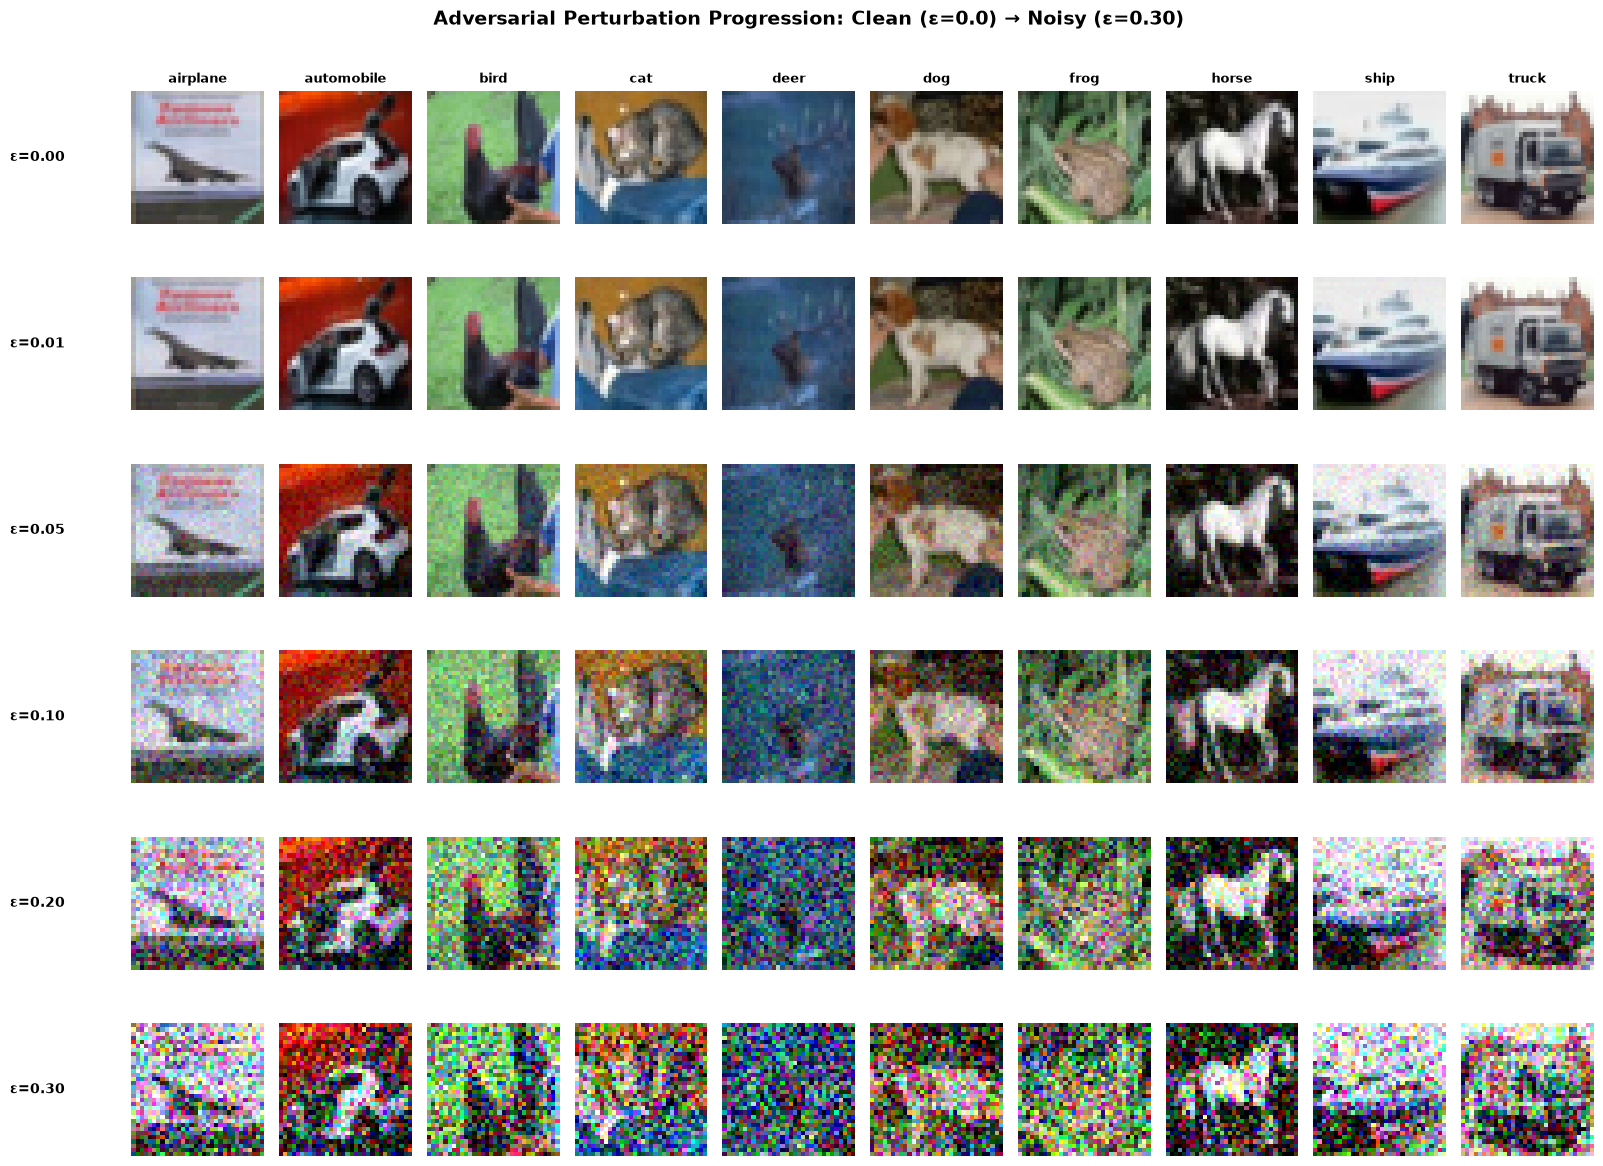

Saved: figures/05_adversarial_examples.png

Observations:
  ε=0.00 → 0.05: Perturbations imperceptible to humans
  ε=0.10 → 0.20: Noise becoming visible but images still recognizable
  ε=0.30: Heavy noise, significantly degrades image quality


In [17]:

# Visualize Adversarial 
# increasing perturbation magnitude makes images progressively noisier.


# Select sample images (one per class)
sample_indices = [np.where(y_test == i)[0][0] for i in range(10)]

fig, axes = plt.subplots(len(epsilon_values), 10, figsize=(16, 12))
fig.suptitle('Adversarial Perturbation Progression: Clean (ε=0.0) → Noisy (ε=0.30)', 
             fontsize=14, fontweight='bold', y=0.995)

for row, eps in enumerate(epsilon_values):
    X_adv_eps = adversarial_results['X_adv_dict'][eps]
    
    for col, idx in enumerate(sample_indices):
        ax = axes[row, col]
        ax.imshow(X_adv_eps[idx])
        ax.axis('off')
        
        # Add labels
        if row == 0:
            ax.set_title(class_names[col], fontsize=9, fontweight='bold')
        if col == 0:
            ax.text(-0.5, 0.5, f'ε={eps:.2f}', transform=ax.transAxes, 
                   fontsize=10, fontweight='bold', va='center', ha='right')

plt.tight_layout()
plt.savefig('figures/05_adversarial_examples.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: figures/05_adversarial_examples.png")
print("\nObservations:")
print("  ε=0.00 → 0.05: Perturbations imperceptible to humans")
print("  ε=0.10 → 0.20: Noise becoming visible but images still recognizable")
print("  ε=0.30: Heavy noise, significantly degrades image quality")

## Per-Class Robustness: Which Classes Are Most Vulnerable?
**Key Question:** Do all classes degrade equally, or are some more vulnerable?
**Connection to EDA:** 
From Assignment 1, we know brightness varies by class:
- Bright classes (airplane, ship): May be MORE robust (higher SNR)
- Dark classes (frog, deer): May be LESS robust (lower SNR)
Let's test this hypothesis empirically.


PER-CLASS ROBUSTNESS ANALYSIS

Class Robustness at ε=0.05 (imperceptible) and ε=0.20 (noticeable):

Class          | Clean Acc | ε=0.05 Acc | ε=0.20 Acc | Drop(0.05) | Drop(0.20)
-------------------------------------------------------------------------------------
ship           | 0.869      | 0.765      | 0.020      | 0.104      | 0.849
deer           | 0.773      | 0.742      | 0.016      | 0.031      | 0.757
automobile     | 0.845      | 0.728      | 0.118      | 0.117      | 0.727
horse          | 0.801      | 0.686      | 0.113      | 0.115      | 0.688
airplane       | 0.766      | 0.613      | 0.085      | 0.153      | 0.681
dog            | 0.707      | 0.560      | 0.045      | 0.147      | 0.662
bird           | 0.618      | 0.396      | 0.071      | 0.222      | 0.547
cat            | 0.507      | 0.387      | 0.038      | 0.120      | 0.469
truck          | 0.830      | 0.835      | 0.488      | -0.005      | 0.342
frog           | 0.857      | 0.937      | 0.996      | -0

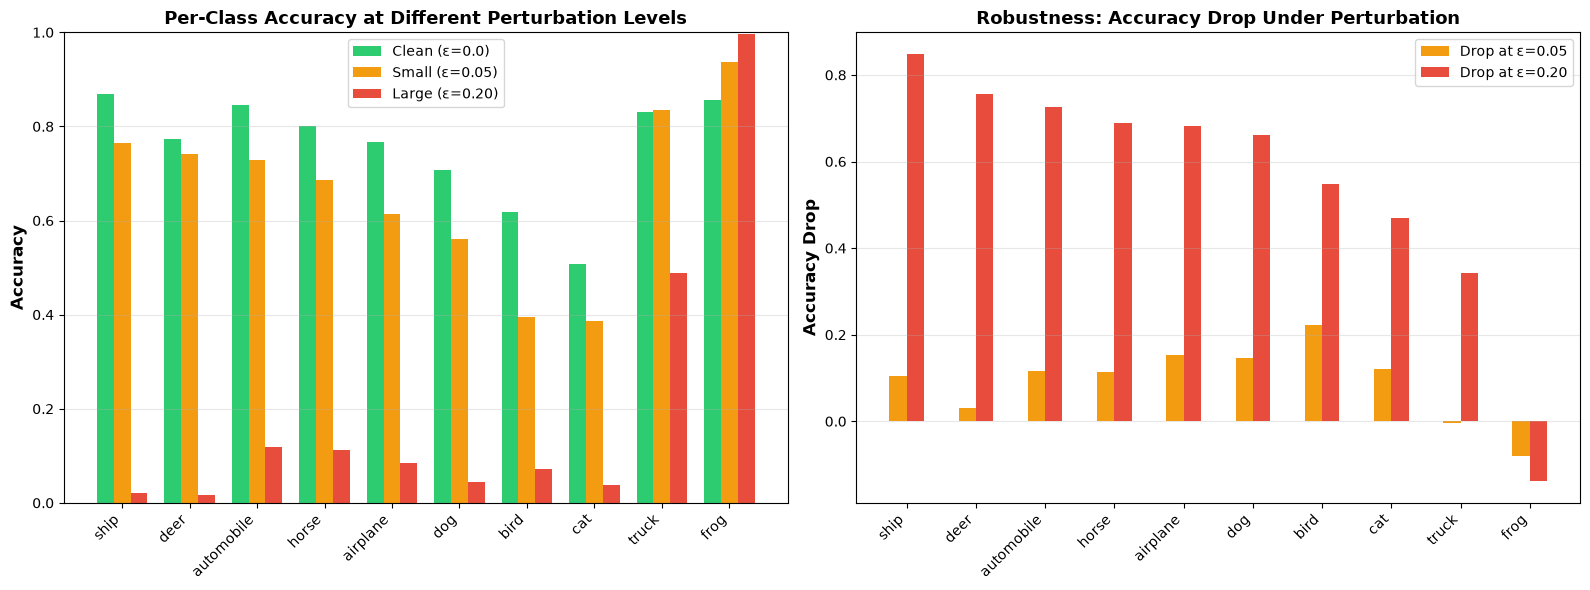


 Saved: figures/05_per_class_robustness.png


In [20]:


print("\n" + "="*40)
print("PER-CLASS ROBUSTNESS ANALYSIS")
print("="*40)

# Select two perturbation levels for detailed analysis
eps_small = 0.05  # Imperceptible
eps_large = 0.20  # Noticeable

# Get predictions at these levels
idx_small = epsilon_values.index(eps_small)
idx_large = epsilon_values.index(eps_large)

y_pred_small = adversarial_results['predictions'][idx_small]
y_pred_large = adversarial_results['predictions'][idx_large]

# Compute per-class accuracy drop
per_class_robustness = []

for class_idx in range(len(class_names)):
    class_mask = (y_test == class_idx)
    
    # Clean accuracy
    acc_clean = (y_pred_clean[class_mask] == y_test[class_mask]).mean()
    
    # Small perturbation accuracy
    acc_small = (y_pred_small[class_mask] == y_test[class_mask]).mean()
    
    # Large perturbation accuracy
    acc_large = (y_pred_large[class_mask] == y_test[class_mask]).mean()
    
    # Robustness metrics
    drop_small = acc_clean - acc_small
    drop_large = acc_clean - acc_large
    
    per_class_robustness.append({
        'class': class_names[class_idx],
        'acc_clean': acc_clean,
        f'acc_eps{eps_small}': acc_small,
        f'acc_eps{eps_large}': acc_large,
        f'drop_eps{eps_small}': drop_small,
        f'drop_eps{eps_large}': drop_large
    })

robustness_df = pd.DataFrame(per_class_robustness)
robustness_df = robustness_df.sort_values('drop_eps0.2', ascending=False)

print(f"\nClass Robustness at ε=0.05 (imperceptible) and ε=0.20 (noticeable):")
print("\nClass          | Clean Acc | ε=0.05 Acc | ε=0.20 Acc | Drop(0.05) | Drop(0.20)")
print("-" * 85)
for _, row in robustness_df.iterrows():
    print(f"{row['class']:14s} | {row['acc_clean']:.3f}      | "
      f"{row['acc_eps0.05']:.3f}      | {row['acc_eps0.2']:.3f}      | "
      f"{row['drop_eps0.05']:.3f}      | {row['drop_eps0.2']:.3f}")
# Visualize per-class robustness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy at different ε levels
x_pos = np.arange(len(class_names))
width = 0.25

acc_clean_vals = [row['acc_clean'] for _, row in robustness_df.iterrows()]
acc_eps05_vals = [row['acc_eps0.05'] for _, row in robustness_df.iterrows()]
acc_eps20_vals = [row['acc_eps0.2'] for _, row in robustness_df.iterrows()]

ax1.bar(x_pos - width, acc_clean_vals, width, label='Clean (ε=0.0)', color='#2ecc71')
ax1.bar(x_pos, acc_eps05_vals, width, label='Small (ε=0.05)', color='#f39c12')
ax1.bar(x_pos + width, acc_eps20_vals, width, label='Large (ε=0.20)', color='#e74c3c')

ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Per-Class Accuracy at Different Perturbation Levels', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(robustness_df['class'], rotation=45, ha='right')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')
ax1.set_ylim([0, 1.0])

# Accuracy drop (robustness metric)
drop_05_vals = [row['drop_eps0.05'] for _, row in robustness_df.iterrows()]
drop_20_vals = [row['drop_eps0.2'] for _, row in robustness_df.iterrows()]

ax2.bar(x_pos - width/2, drop_05_vals, width, label='Drop at ε=0.05', color='#f39c12')
ax2.bar(x_pos + width/2, drop_20_vals, width, label='Drop at ε=0.20', color='#e74c3c')

ax2.set_ylabel('Accuracy Drop', fontsize=12, fontweight='bold')
ax2.set_title('Robustness: Accuracy Drop Under Perturbation', 
              fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(robustness_df['class'], rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/05_per_class_robustness.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved: figures/05_per_class_robustness.png")


## Testing Assignment 1 Hypothesis: Brightness vs Robustness
**Hypothesis from Assignment 1 EDA:**
Classes with higher brightness may be more robust because:
- Higher signal-to-noise ratio (SNR)
- Noise is proportionally smaller relative to signal
- Model has more discriminative features to work with
**Class Brightness (from Assignment 1):**
- Airplane: 0.558 (brightest)
- Ship: 0.523
- Truck: 0.487
- Bird: 0.468
- Horse: 0.466
- Dog: 0.460
- Automobile: 0.458
- Cat: 0.456
- Deer: 0.438
- Frog: 0.418 (darkest)
**Test:** Correlate brightness with robustness



BRIGHTNESS vs ROBUSTNESS ANALYSIS

Correlation between Brightness and Accuracy Drop:
  At ε=0.05: 0.427
  At ε=0.20: 0.478

Interpretation:
   WEAK correlation: Some effect but not dominant


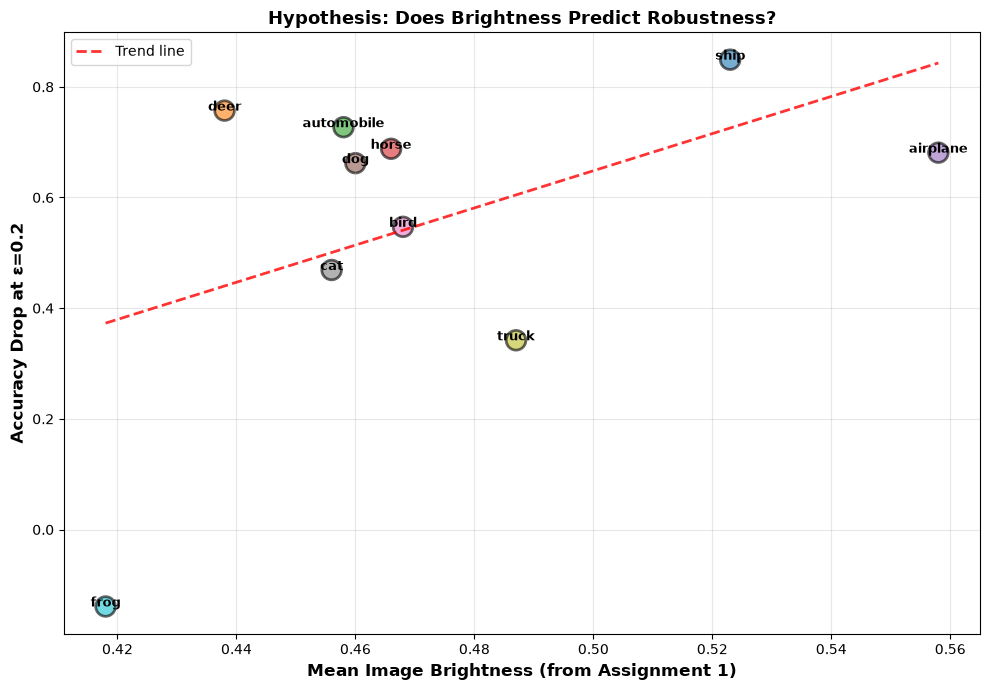


 Saved: figures/05_brightness_robustness_hypothesis.png


In [28]:
brightness_values = {
    'airplane': 0.558,
    'ship': 0.523,
    'truck': 0.487,
    'bird': 0.468,
    'horse': 0.466,
    'dog': 0.460,
    'automobile': 0.458,
    'cat': 0.456,
    'deer': 0.438,
    'frog': 0.418
}

# Add brightness to robustness dataframe
robustness_df['brightness'] = robustness_df['class'].map(brightness_values)

# Compute correlations
eps_05_brightness_corr = robustness_df['drop_eps0.05'].corr(robustness_df['brightness'])
eps_20_brightness_corr = robustness_df['drop_eps0.2'].corr(robustness_df['brightness'])

print("\n" + "="*50)
print("BRIGHTNESS vs ROBUSTNESS ANALYSIS")
print("="*50)

print(f"\nCorrelation between Brightness and Accuracy Drop:")
print(f"  At ε=0.05: {eps_05_brightness_corr:.3f}")
print(f"  At ε=0.20: {eps_20_brightness_corr:.3f}")

# Interpretation
print("\nInterpretation:")
if eps_05_brightness_corr > 0.5:
    print("   STRONG correlation: Brighter classes ARE more robust")
    print("  → Higher SNR hypothesis confirmed")
elif eps_05_brightness_corr > 0.0:
    print("   WEAK correlation: Some effect but not dominant")
else:
    print("   NO correlation or inverse: Brightness doesn't predict robustness")
    print("  → Other factors matter more (texture, complexity, etc.)")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(robustness_df['brightness'], robustness_df['drop_eps0.2'], 
                    s=200, alpha=0.6, c=range(10), cmap='tab10', edgecolor='black', linewidth=2)

# Add labels for each point
for idx, row in robustness_df.iterrows():
    ax.annotate(row['class'], (row['brightness'], row['drop_eps0.2']), 
               fontsize=9, fontweight='bold', ha='center')

# Add trend line
z = np.polyfit(robustness_df['brightness'], robustness_df['drop_eps0.2'], 1)
p = np.poly1d(z)
x_trend = np.linspace(robustness_df['brightness'].min(), 
                     robustness_df['brightness'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend line')

ax.set_xlabel('Mean Image Brightness (from Assignment 1)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy Drop at ε=0.2', fontsize=12, fontweight='bold')
ax.set_title('Hypothesis: Does Brightness Predict Robustness?', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/05_brightness_robustness_hypothesis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved: figures/05_brightness_robustness_hypothesis.png")

In [29]:


os.makedirs('results', exist_ok=True)

# Save all adversarial results
adv_results_summary = {
    'epsilon_values': epsilon_values,
    'accuracies': adversarial_results['accuracies'],
    'baseline_accuracy': baseline_accuracy,
    'per_class_robustness': per_class_robustness,
    'robustness_df': robustness_df.to_dict(),
    'brightness_correlation_eps05': eps_05_brightness_corr,
    'brightness_correlation_eps20': eps_20_brightness_corr,
    'X_adv_dict': adversarial_results['X_adv_dict']
}

with open('results/adversarial_results.pkl', 'wb') as f:
    pickle.dump(adv_results_summary, f)

print("\n" + "="*70)
print(" ADVERSARIAL PERTURBATION ANALYSIS COMPLETE")
print("="*70)

print("\nResults Summary:")
print(f"  • Baseline (clean) accuracy: {baseline_accuracy:.4f}")
print(f"  • Accuracy at ε=0.05 (imperceptible): {adversarial_results['accuracies'][2]:.4f}")
print(f"  • Accuracy at ε=0.20 (noticeable): {adversarial_results['accuracies'][4]:.4f}")
print(f"  • Brightness-robustness correlation: {eps_20_brightness_corr:.3f}")

print("\nSaved: results/adversarial_results.pkl")



 ADVERSARIAL PERTURBATION ANALYSIS COMPLETE

Results Summary:
  • Baseline (clean) accuracy: 0.7573
  • Accuracy at ε=0.05 (imperceptible): 0.6649
  • Accuracy at ε=0.20 (noticeable): 0.1990
  • Brightness-robustness correlation: 0.478

Saved: results/adversarial_results.pkl
